In [1]:
import OptimalBattery.simulate as sim
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import OptimalBattery.simulate as sim
import torch as pt
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import OptimalBattery.construct as ct
import OptimalBattery.util as ut
import OptimalBattery.estimate as et
import seaborn as sns
from scipy.stats import gamma


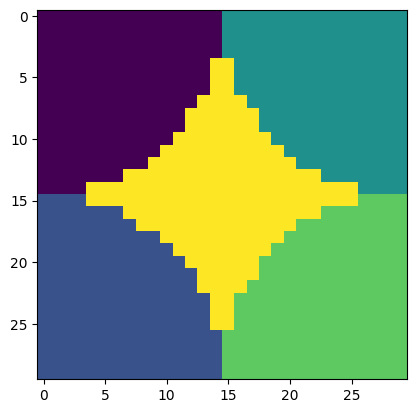

In [2]:
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")

grid_height = 30
grid_width = 30

U_true_5 = sim.make_U_spatial(height=grid_height, width=grid_width, K_main= 5)
U_true_5 = pt.from_numpy(U_true_5).to(device)

labels = pt.argmax(U_true_5, axis=0)          
label_map = labels.reshape(grid_height, grid_width)           
plt.imshow(label_map.cpu().numpy())
plt.show()

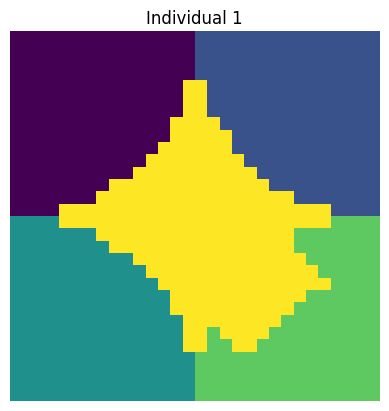

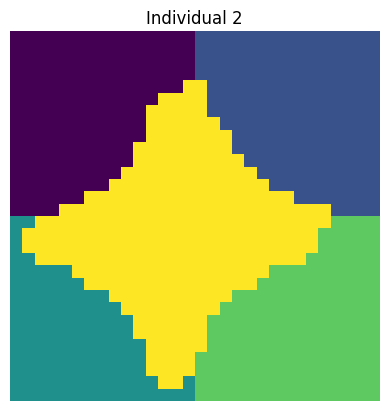

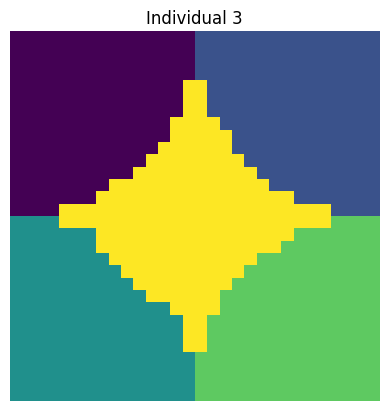

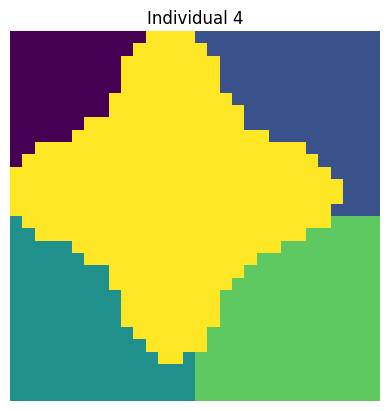

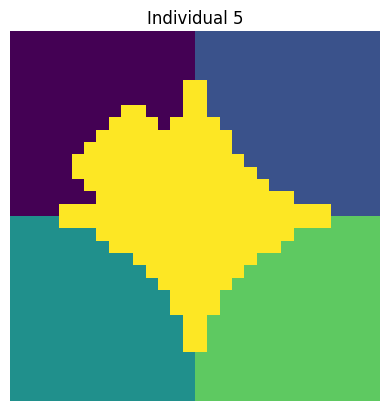

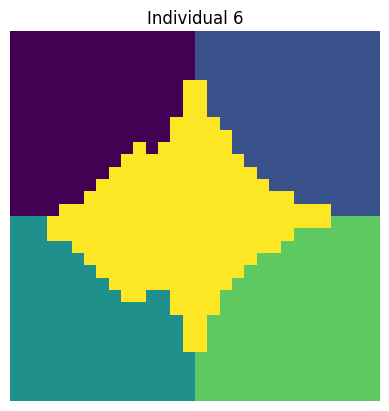

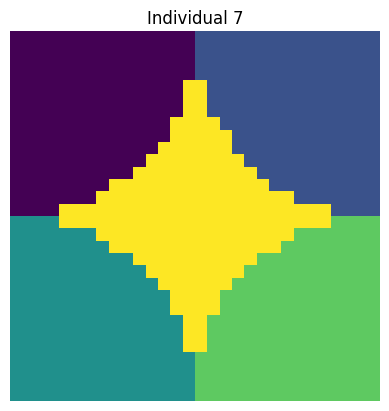

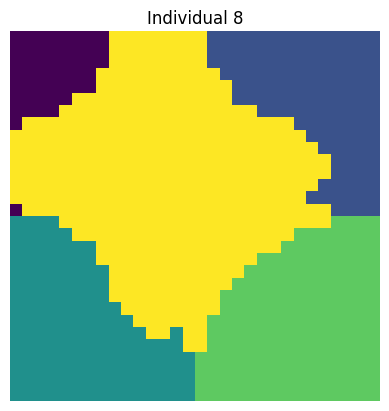

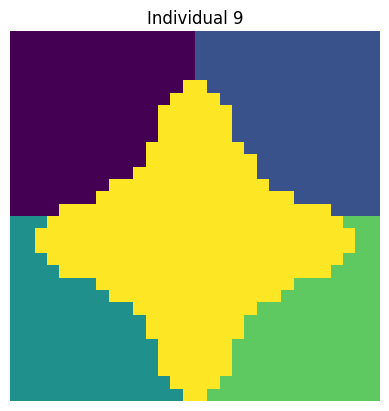

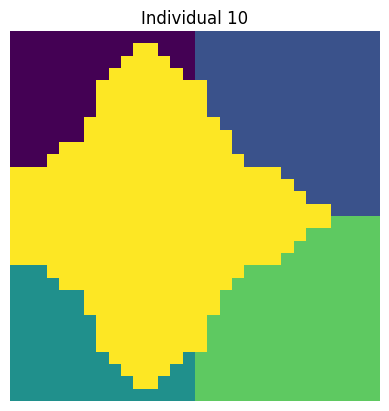

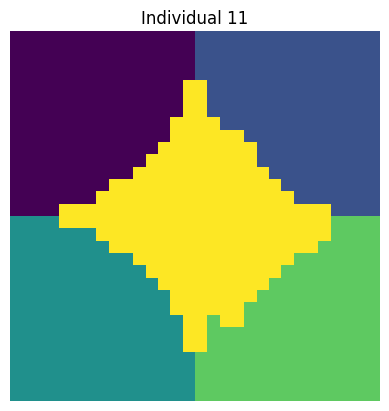

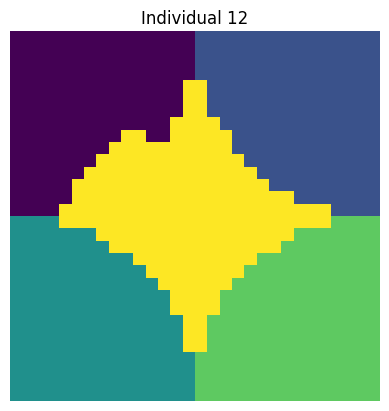

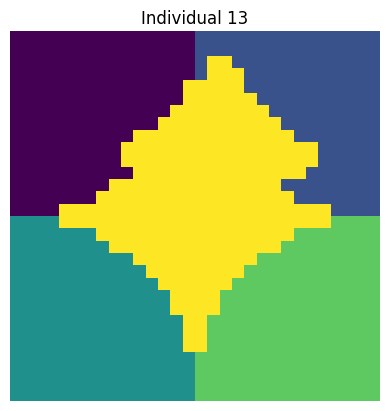

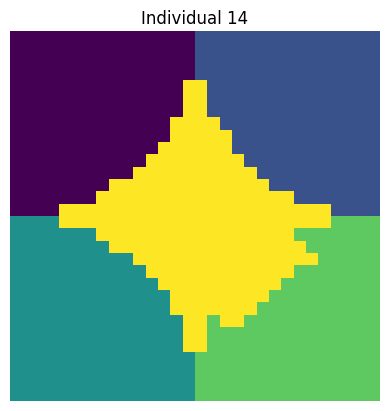

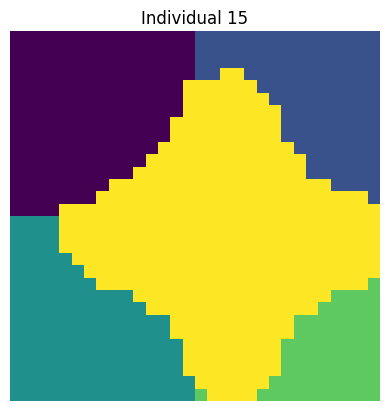

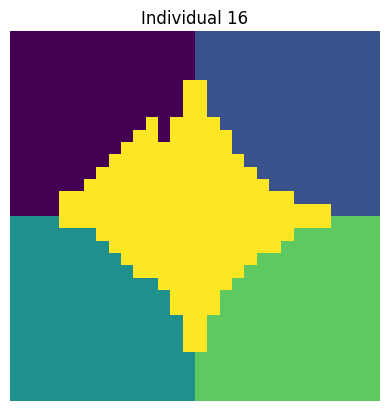

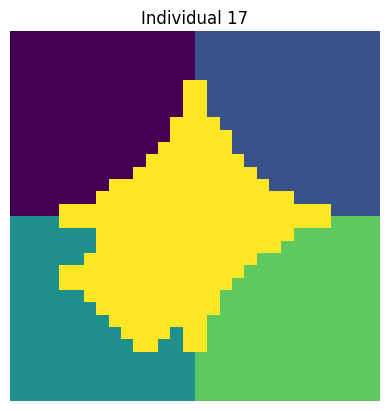

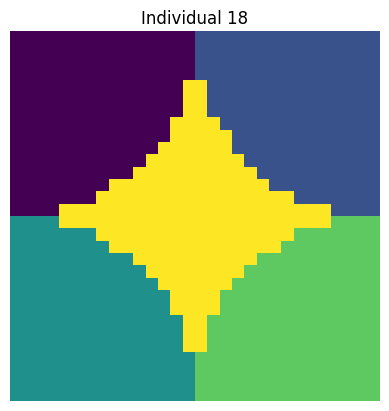

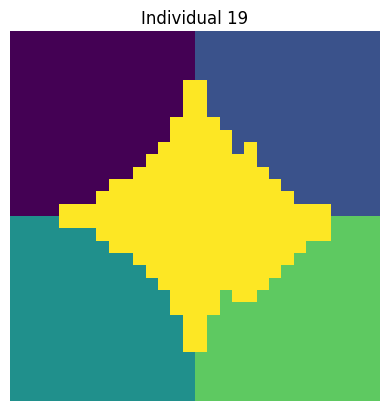

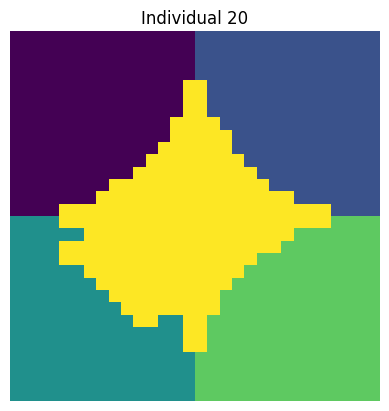

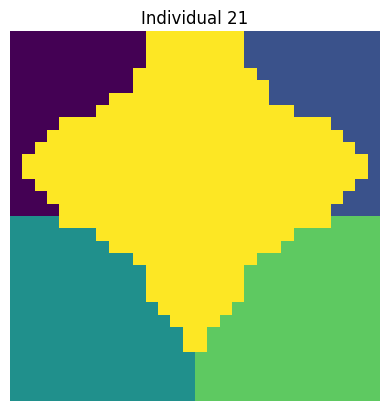

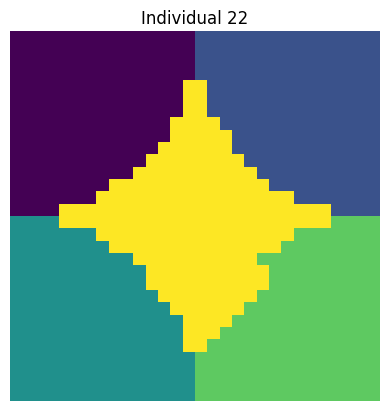

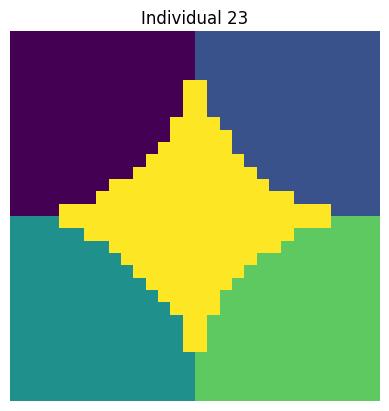

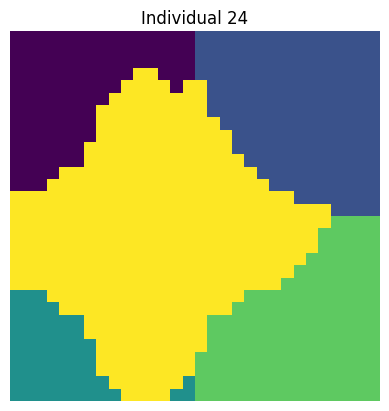

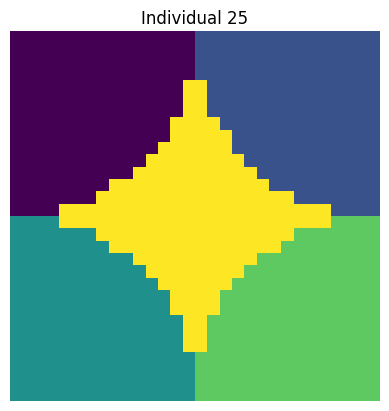

In [3]:
U_individuals = sim.make_U_individuals(
    U_true_5, grid_height,grid_width,
    n_individuals=500,
    shift_range=5,    # more realistic positional variability
    size_jitter=3,   # allows up to ~3× size range
    seed= None,
    device=device
)

for i, U in enumerate(U_individuals[:25]):
    label_map = np.argmax(U.cpu().numpy(), axis=0).reshape(grid_width, grid_height)
    plt.imshow(label_map.T)
    plt.title(f'Individual {i+1}')
    plt.axis('off')
    plt.show()

# make collpased versions of U_individuals (Region of interest and everything else)
U_individuals_collapsed = []
target_indices = [4]
for U_ind in U_individuals:
    U_collapsed = sim.collapse_U(U_ind, target_parcels_indices=target_indices)
    U_individuals_collapsed.append(U_collapsed)


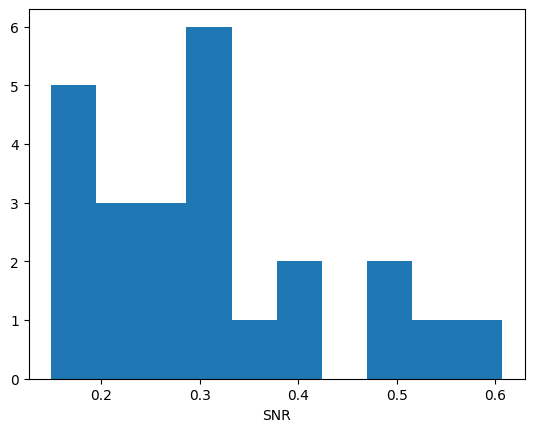

In [4]:
snr_list = [0.31151517746083324, 0.4149032130622417, 0.2109707527775373, 0.60686115368927, 0.16579936476988083, 0.395539359540918, 0.5078137659693904, 0.27229704833431684, 0.21302458761490056, 0.31680924605275873, 0.5421971847979179, 0.19353280287277416, 0.31851524087316907, 0.34928780858272923, 0.1691889901956513, 0.48328088358127114, 0.3095999179473811, 0.2875932193289647, 0.26323265507633903, 0.32217110978990227, 0.2552691555387832, 0.1969497723202638, 0.1679326909051331, 0.14889751190941908]
shape, loc, scale = gamma.fit(snr_list, floc=0)  
x = np.linspace(min(snr_list), max(snr_list), 200)
plt.hist(snr_list, bins=10)
plt.xlabel("SNR")
plt.show()

In [5]:
threshold_values = [0.3]  # example thresholds
results_all = []
for th in threshold_values:
    results_df, parcellations_single, parcellations_multi = sim.sim_single_vs_multi(
        U_individuals,
        U_individuals_collapsed,
        base_noise=0.2,
        snr_ratios=snr_list,
        single_threshold=th
    )
    results_df["threshold"] = th  # tag the results
    results_all.append(results_df)

results_concat = pd.concat(results_all, ignore_index=True)


In [6]:
grouped = results_concat.groupby("threshold")[["true_size", "predicted_size"]].mean()

# Print neatly
print('parcel of interest size comparison:')
print(grouped)

everything_else_grouped = results_concat.groupby("threshold")[["true_everything_size", "predicted_everything_size"]].mean()

print('everything else size comparison:')
print(everything_else_grouped)

parcel of interest size comparison:
           true_size  predicted_size
threshold                           
0.3           267.17         263.843
everything else size comparison:
           true_everything_size  predicted_everything_size
threshold                                                 
0.3                      632.83                    636.157


In [7]:
def plot_results_subplots_by_threshold(df):
    """Plot 3 metrics (Predicted vs SNR, Predicted vs True, Accuracy vs SNR)
    for each threshold value as separate rows, with matched axes."""
    
    thresholds = sorted(df["threshold"].unique())
    n_th = len(thresholds)

    # Compute global min/max for matching axes
    snr_min, snr_max = df["snr_factor"].min(), df["snr_factor"].max()
    size_min, size_max = df[["true_size", "predicted_size"]].min().min(), df[["true_size", "predicted_size"]].max().max()
    acc_min, acc_max = df["accuracy"].min(), df["accuracy"].max()

    fig, axes = plt.subplots(n_th, 3, figsize=(18, 5 * n_th), squeeze=False)

    for i, th in enumerate(thresholds):
        sub_df = df[df["threshold"] == th]

        # 1️⃣ Predicted size vs SNR
        sns.scatterplot(
            data=sub_df,
            x="snr_factor",
            y="predicted_size",
            hue="type",
            marker="o",
            ax=axes[i, 0]
        )
        axes[i, 0].set(xlim=(snr_min, snr_max), ylim=(0, size_max))
        axes[i, 0].set_xlabel("SNR factor")
        axes[i, 0].set_ylabel("Predicted size")
        axes[i, 0].set_title(f"Predicted size vs SNR\n(threshold={th})")

        # 2️⃣ Predicted vs True size
        sns.scatterplot(
            data=sub_df,
            x="true_size",
            y="predicted_size",
            hue="type",
            marker="o",
            ax=axes[i, 1]
        )
        axes[i, 1].set_xlim(size_min, size_max)
        axes[i, 1].set_ylim(size_min, size_max)
        axes[i, 1].set_xlabel("True size")
        axes[i, 1].set_ylabel("Predicted size")
        axes[i, 1].set_title(f"Predicted vs True size\n(threshold={th})")

        # 3️⃣ Accuracy vs SNR
        sns.scatterplot(
            data=sub_df,
            x="snr_factor",
            y="accuracy",
            hue="type",
            marker="o",
            ax=axes[i, 2]
        )
        axes[i, 2].set(xlim=(snr_min, snr_max), ylim=(acc_min, acc_max))
        axes[i, 2].set_xlabel("SNR factor")
        axes[i, 2].set_ylabel("Accuracy")
        axes[i, 2].set_title(f"Accuracy vs SNR\n(threshold={th})")

        # Clean up legends for this row
        for j in range(3):
            axes[i, j].legend().set_title("Condition type")

    plt.tight_layout()
    plt.show()




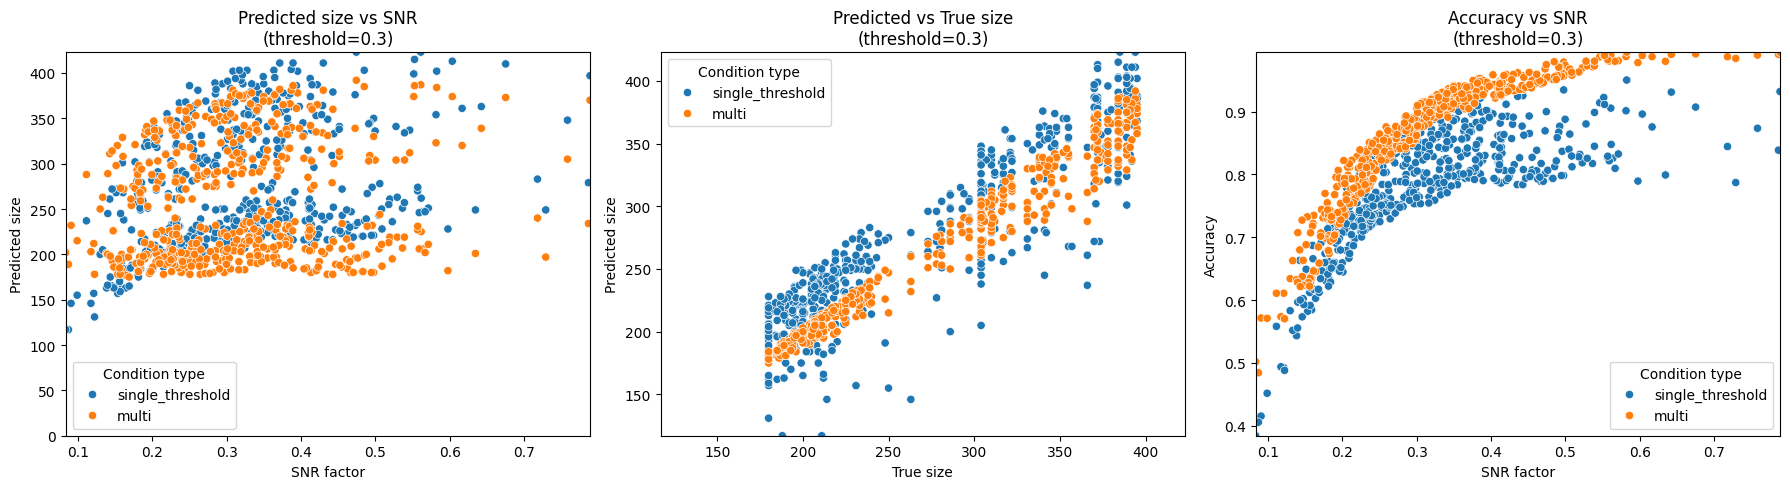

In [8]:
plot_results_subplots_by_threshold(results_concat)


In [9]:
corr_by_type = (
    results_concat.groupby("type")
      .apply(lambda g: g["predicted_size"].corr(g["snr_factor"]))
      .reset_index(name="pearson_corr")
)

print(corr_by_type)


               type  pearson_corr
0             multi      0.109601
1  single_threshold      0.348271


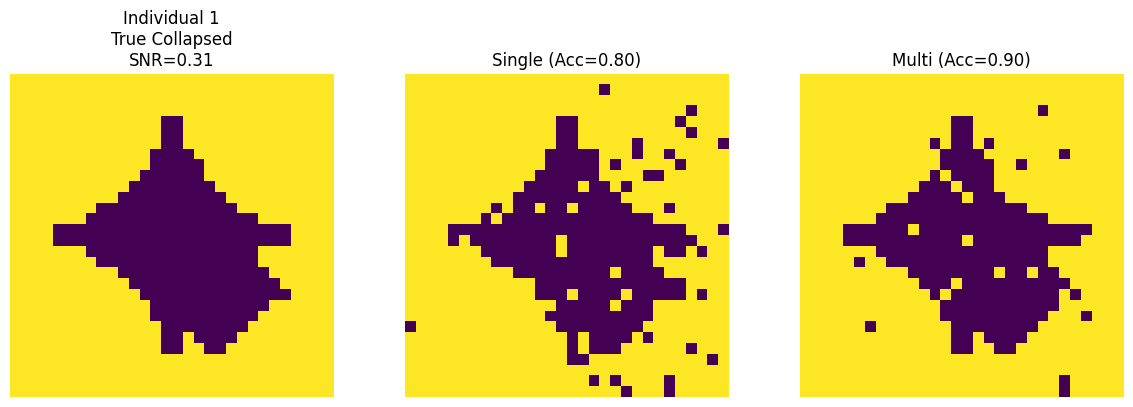

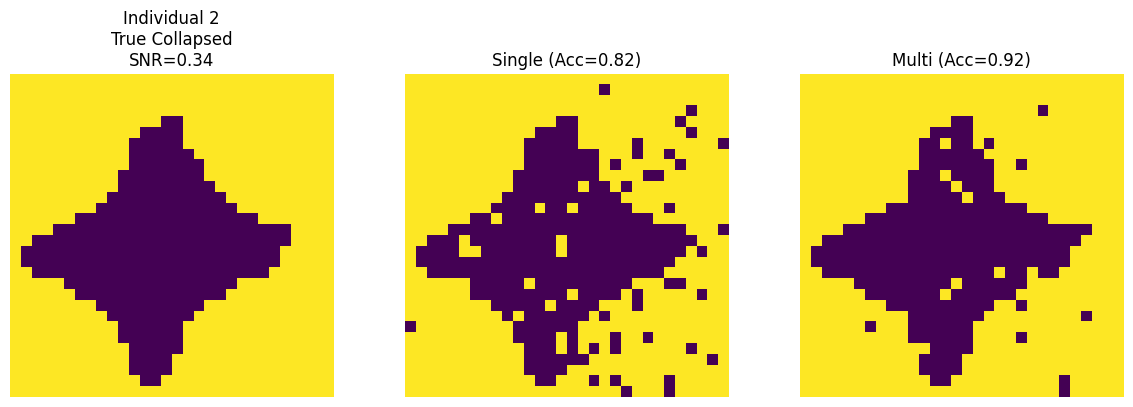

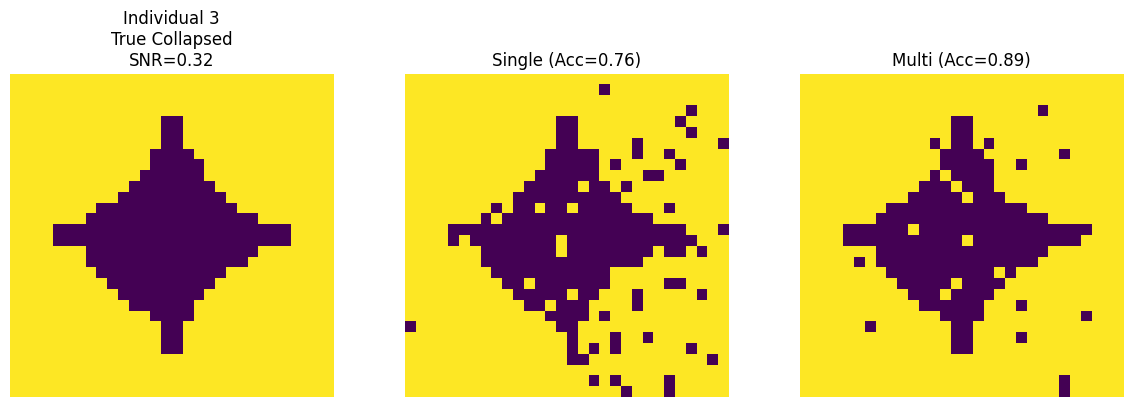

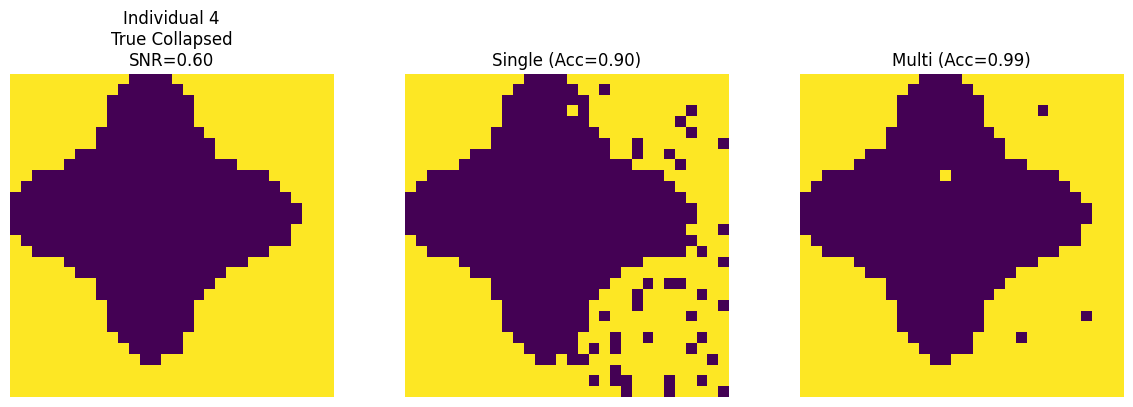

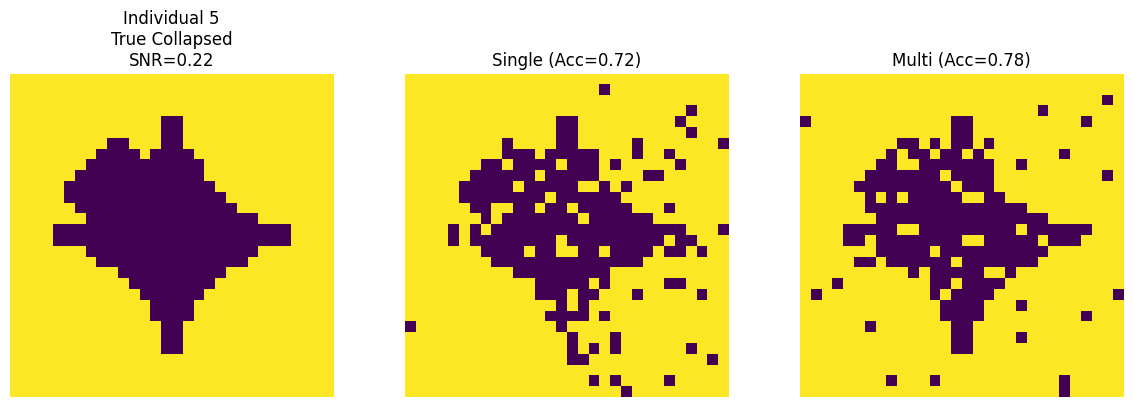

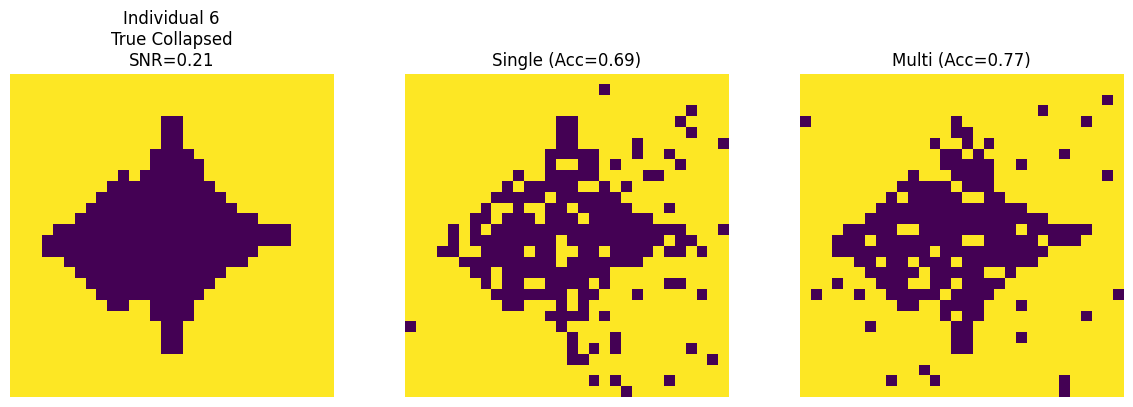

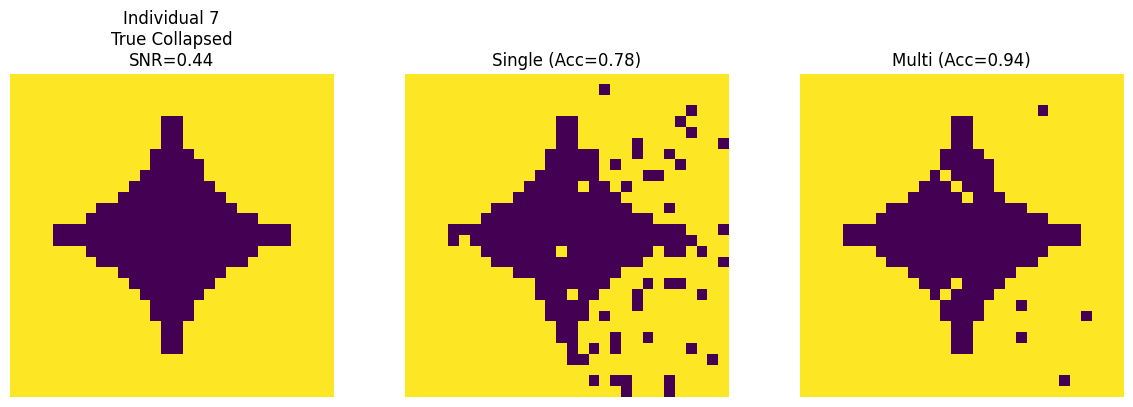

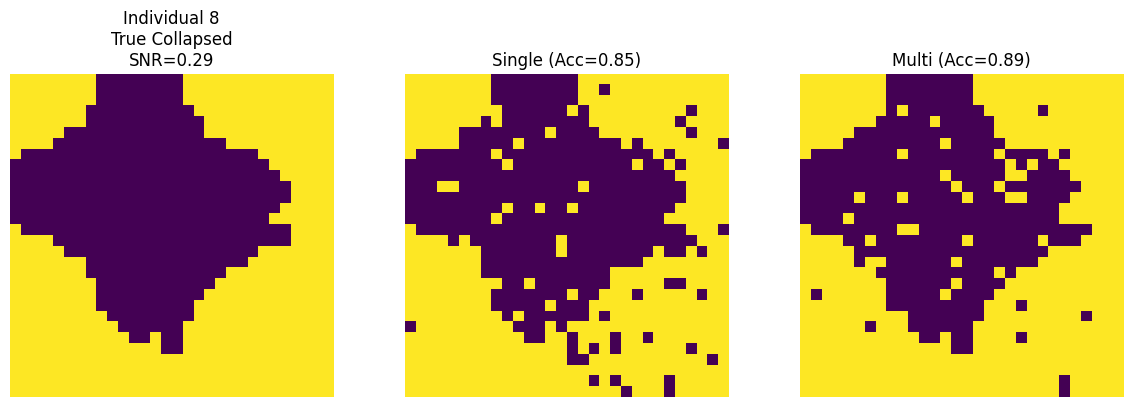

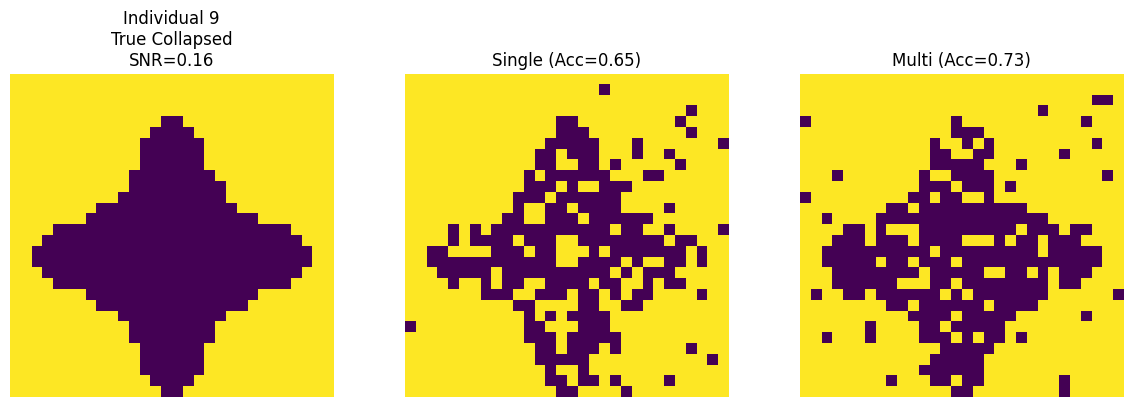

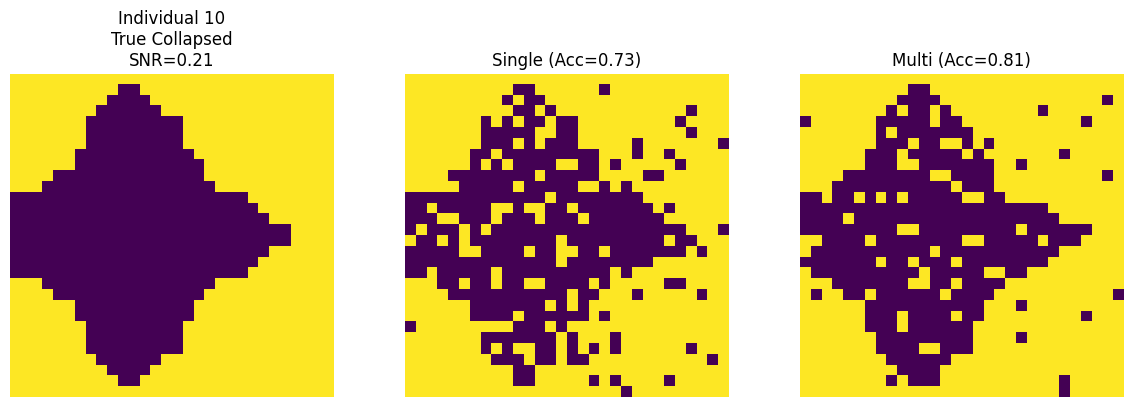

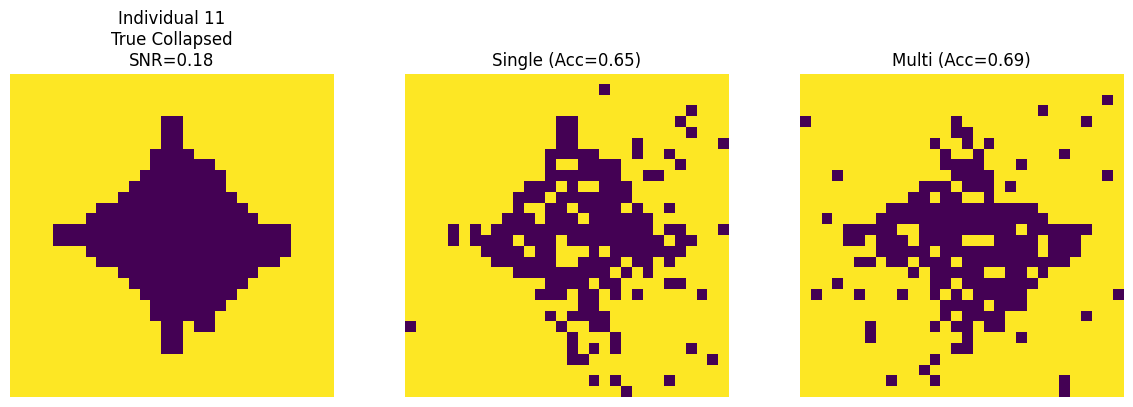

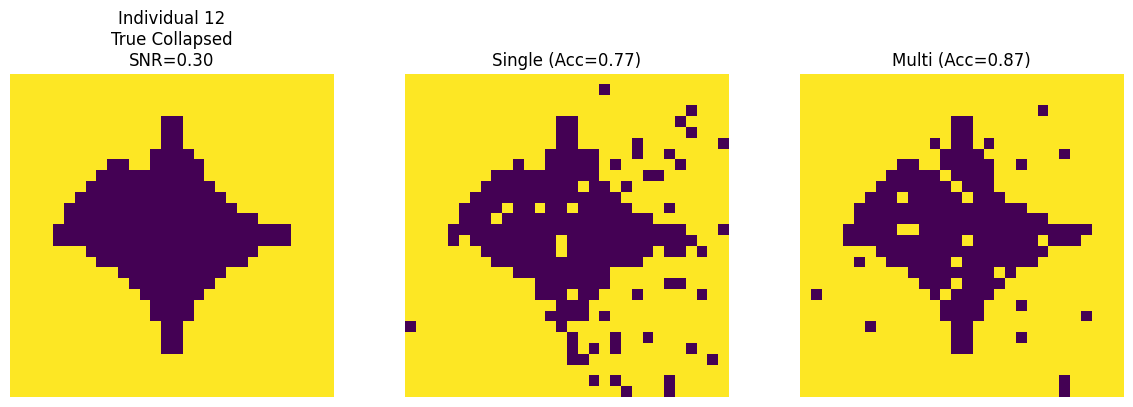

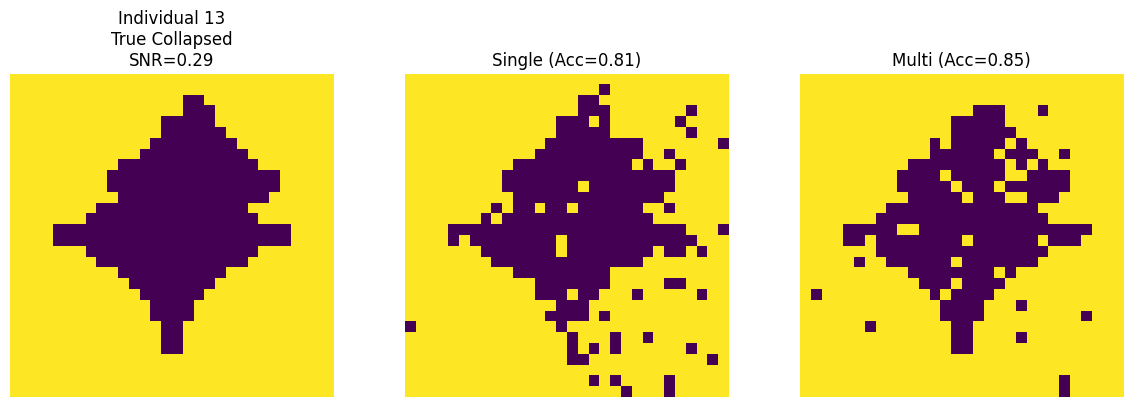

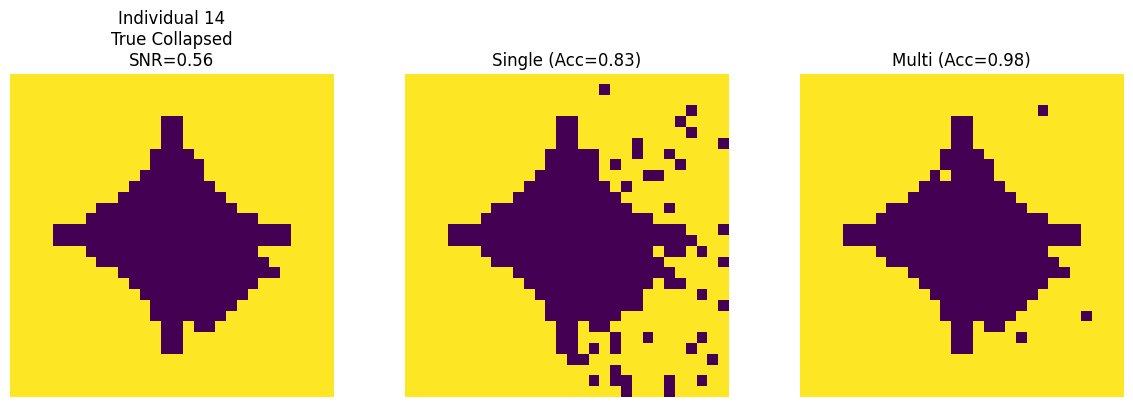

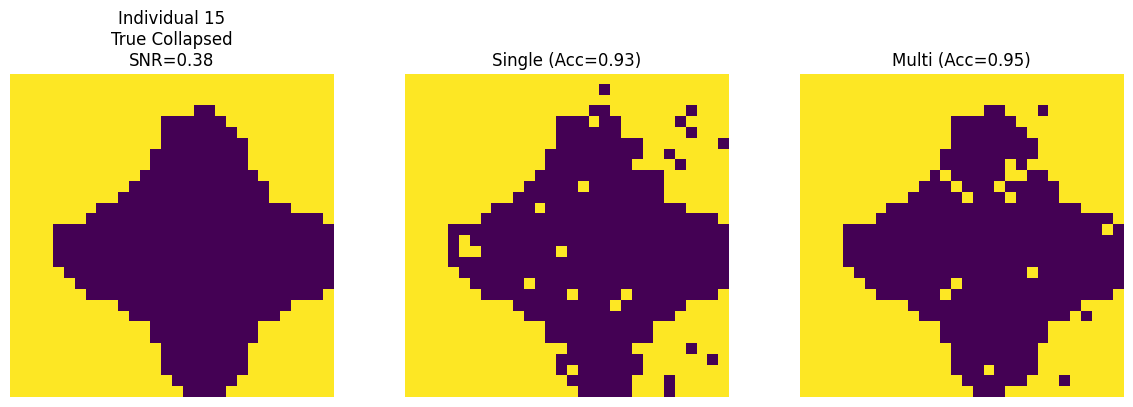

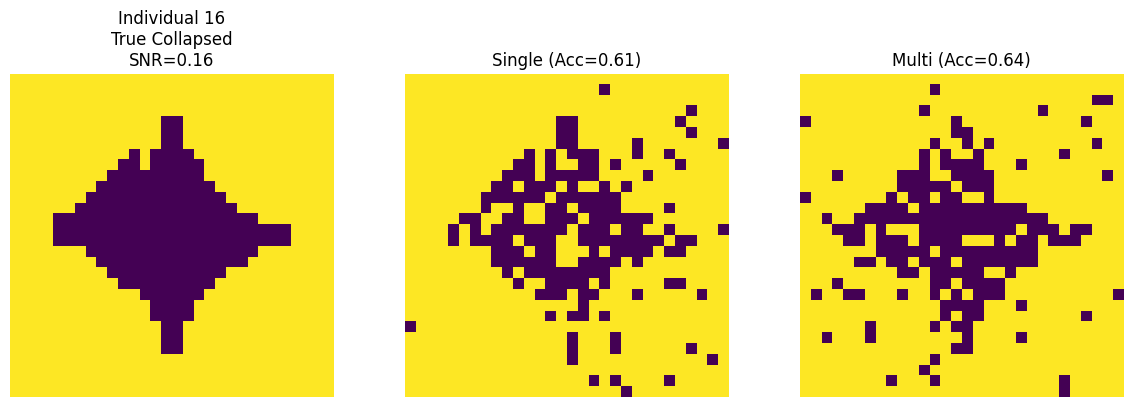

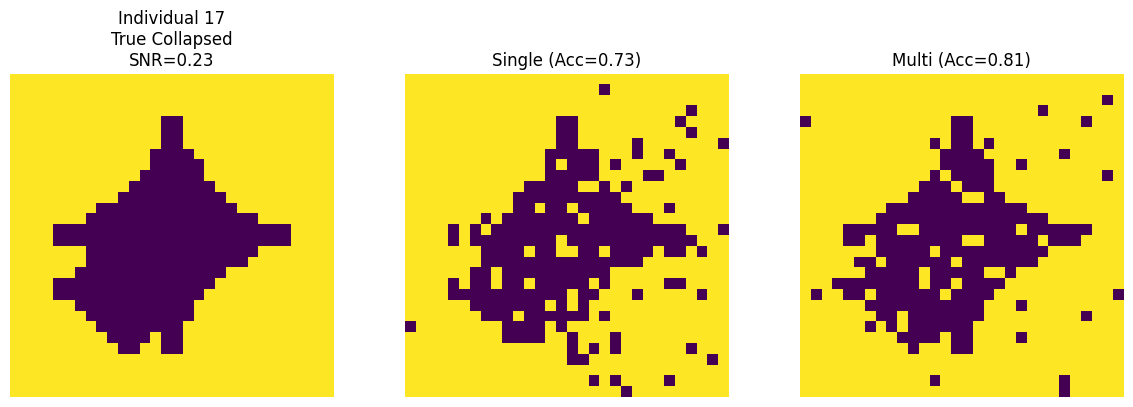

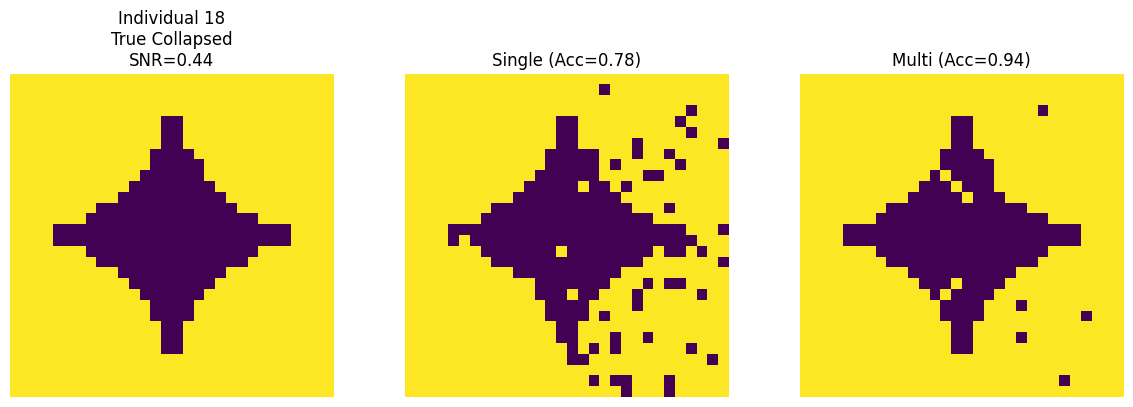

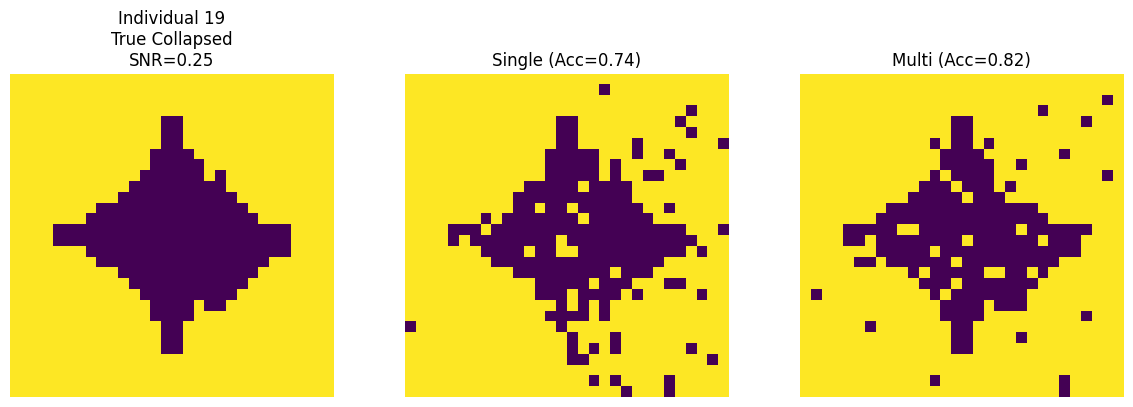

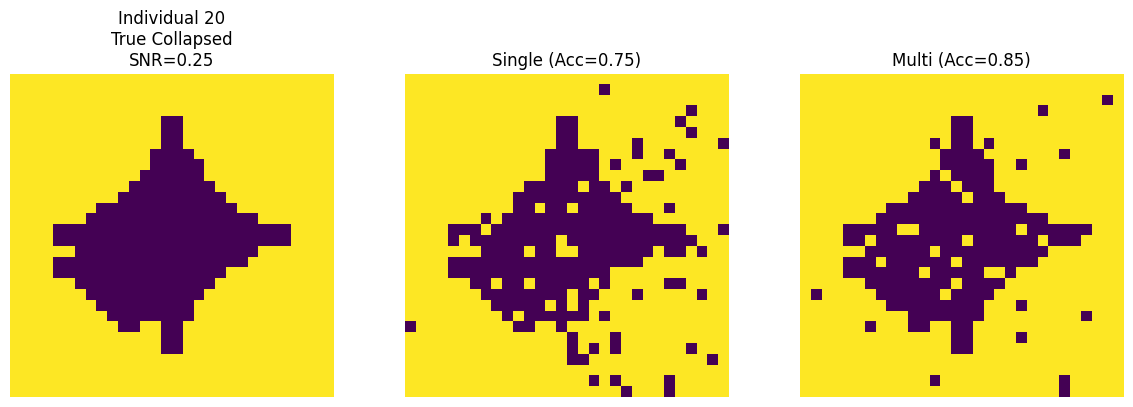

In [10]:
n_individuals = len(U_individuals_collapsed)
results_df = results_concat
for i in range(20):
    # Extract metrics for this individual
    snr_factor = results_df[results_df['individual'] == i]['snr_factor'].values
    snr_factor = snr_factor[0] if len(snr_factor) > 0 else np.nan

    acc_single = results_df[(results_df['individual'] == i) & (results_df['type'] == 'single_threshold')]['accuracy'].values
    acc_multi  = results_df[(results_df['individual'] == i) & (results_df['type'] == 'multi')]['accuracy'].values
    
    acc_single = acc_single[0] if len(acc_single) > 0 else np.nan
    acc_multi  = acc_multi[0] if len(acc_multi) > 0 else np.nan

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # --- True Collapsed ---
    true_label = np.argmax(U_individuals_collapsed[i].cpu().numpy(), axis=0).reshape(grid_width, grid_height)
    axes[0].imshow(true_label.T, cmap='viridis')
    axes[0].set_title(f'Individual {i+1}\nTrue Collapsed\nSNR={snr_factor:.2f}')
    axes[0].axis('off')
    
    # --- Single Threshold Estimate ---
    single_label = np.argmax(parcellations_single[i], axis=0).reshape(grid_width, grid_height)
    axes[1].imshow(single_label.T, cmap='viridis')
    axes[1].set_title(f'Single (Acc={acc_single:.2f})')
    axes[1].axis('off')
    
    # --- Multi Contrast Estimate ---
    multi_label = np.argmax(parcellations_multi[i], axis=0).reshape(grid_width, grid_height)
    axes[2].imshow(multi_label.T, cmap='viridis')
    axes[2].set_title(f'Multi (Acc={acc_multi:.2f})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


